In [9]:
import pandas as pd
from malaria_outbreak_model_1 import MalariaOutbreakModel

FEATURES = ["temp_c","rh_pct","rain_mm","soil_moisture_top_m3m3","wind10_kmh"]

# 1) Load weekly historical data (may contain strings like "1,102")
hist_df = pd.read_csv("Data/historical_malaria_data.csv")

# 2) Fit — module will clean commas/percents/whitespace automatically
model = MalariaOutbreakModel(outbreak_ratio=1.5, random_state=7)
model.fit(hist_df, target_col="cases", feature_cols=FEATURES)  # schema locked

# 3) Load 2–6 week weather forecast (same FEATURES, no 'cases')
weeks_df = pd.read_csv("Data/forecast_weather.csv")

# # 4) Predict weekly cases + outbreak flag (pred_t / pred_(t-1) > 1.5)
# preds = model.predict_and_flag_current(weeks_df, week_col="week")

# 4) Predict weekly cases + outbreak flag (pred_t / pred_(t-1) > 1.5)
preds = model.predict_and_flag_current(weeks_df, week_col="week")

# Add the ratio used for the flag
preds["growth_ratio"] = preds["pred_cases"] / preds["pred_cases"].shift(1)
preds["growth_ratio"] = preds["growth_ratio"].round(2)  # optional

# Print with whichever week column you have (week or week_index)
cols = [c for c in ["week", "week_index", "pred_cases", "growth_ratio", "outbreak_flag"] if c in preds.columns]
print(preds[cols])

# print(preds)

   week_index   pred_cases  growth_ratio  outbreak_flag
0           0  1461.062431           NaN          False
1           1  2474.659043          1.69           True
2           2  4127.574777          1.67           True
3           3  3221.211493          0.78          False
4           4  2706.033408          0.84          False
5           5  2162.807620          0.80          False
6           6  3383.383087          1.56           True
7           7  1934.965262          0.57          False
8           8  2761.756630          1.43          False


C:\Users\HRumenya\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [10]:
preds['pred_cases']

0    1461.062431
1    2474.659043
2    4127.574777
3    3221.211493
4    2706.033408
5    2162.807620
6    3383.383087
7    1934.965262
8    2761.756630
Name: pred_cases, dtype: float64

In [11]:
actuals = pd.read_csv("Data/Actual_malaria_cases.csv")

In [12]:
actuals

,week_start,actual_cases
0,7/7/2025,"2,493"
1,7/14/2025,"2,792"
2,7/21/2025,"1,926"
3,7/28/2025,"2,364"
4,8/4/2025,"3,030"
5,8/11/2025,"2,999"
6,8/18/2025,"2,024"
7,8/25/2025,"2,494"
8,9/1/2025,"2,776"


In [13]:
# Clean actuals numeric
actuals_clean = actuals.copy()
actuals_clean["actual_cases"] = (
    actuals_clean["actual_cases"].astype(str).str.replace(",", "", regex=False).astype(float)
)

# Align by position using auto-generated indexes
merged = (
    preds.reset_index(drop=True)
    .join(actuals_clean[["actual_cases"]].reset_index(drop=True))
)

print(merged)

   week_index   pred_cases  outbreak_flag  growth_ratio  actual_cases
0           0  1461.062431          False           NaN        2493.0
1           1  2474.659043           True          1.69        2792.0
2           2  4127.574777           True          1.67        1926.0
3           3  3221.211493          False          0.78        2364.0
4           4  2706.033408          False          0.84        3030.0
5           5  2162.807620          False          0.80        2999.0
6           6  3383.383087           True          1.56        2024.0
7           7  1934.965262          False          0.57        2494.0
8           8  2761.756630          False          1.43        2776.0


In [14]:
# Clean + prepare actuals
actuals_clean = actuals.copy()
actuals_clean["week_start"] = pd.to_datetime(actuals_clean["week_start"])
actuals_clean["actual_cases"] = (
    actuals_clean["actual_cases"].astype(str).str.replace(",", "", regex=False).astype(float)
)

# (optional) add the ratio to preds
preds = preds.copy()
preds["growth_ratio"] = preds["pred_cases"] / preds["pred_cases"].shift(1)

# Align by position (trim to overlap if lengths differ)
n = min(len(preds), len(actuals_clean))
merged = (
    preds.reset_index(drop=True).iloc[:n]
    .join(actuals_clean[["week_start", "actual_cases"]].reset_index(drop=True).iloc[:n])
)

print(merged[["week_start", "actual_cases","pred_cases", "growth_ratio", "outbreak_flag"]])


  week_start  actual_cases   pred_cases  growth_ratio  outbreak_flag
0 2025-07-07        2493.0  1461.062431           NaN          False
1 2025-07-14        2792.0  2474.659043      1.693739           True
2 2025-07-21        1926.0  4127.574777      1.667937           True
3 2025-07-28        2364.0  3221.211493      0.780413          False
4 2025-08-04        3030.0  2706.033408      0.840067          False
5 2025-08-11        2999.0  2162.807620      0.799254          False
6 2025-08-18        2024.0  3383.383087      1.564348           True
7 2025-08-25        2494.0  1934.965262      0.571903          False
8 2025-09-01        2776.0  2761.756630      1.427290          False


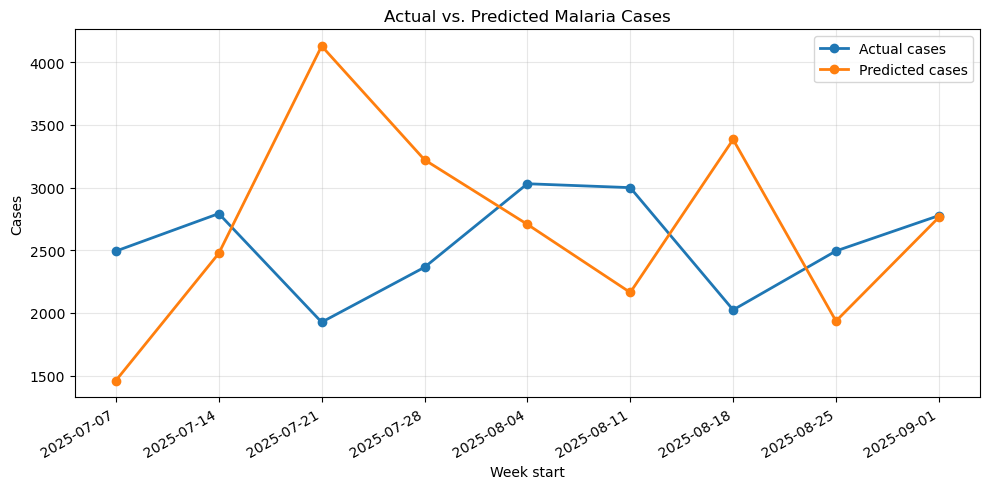

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Make a safe, sorted copy and ensure types are correct
df = merged.copy()
df["week_start"] = pd.to_datetime(df["week_start"])
df["actual_cases"] = pd.to_numeric(df["actual_cases"], errors="coerce")
df["pred_cases"]   = pd.to_numeric(df["pred_cases"], errors="coerce").round(0)
df = df.sort_values("week_start")

# Plot: double line (actual vs. predicted)
plt.figure(figsize=(10, 5))
plt.plot(df["week_start"], df["actual_cases"], linewidth=2, marker="o", label="Actual cases")
plt.plot(df["week_start"], df["pred_cases"],   linewidth=2, marker="o", label="Predicted cases")

plt.title("Actual vs. Predicted Malaria Cases")
plt.xlabel("Week start")
plt.ylabel("Cases")
plt.grid(True, alpha=0.3)
plt.legend()

# Nice date ticks
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()